<a href="https://colab.research.google.com/github/Diego-Cano-bit/CIMAT-Monterrey/blob/main/C%C3%B3digo_CIMAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Visualización de grafica**

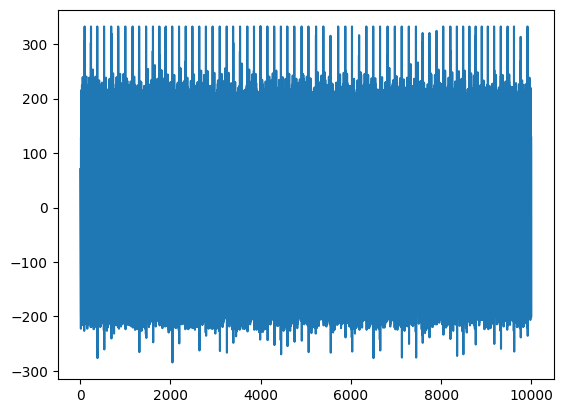

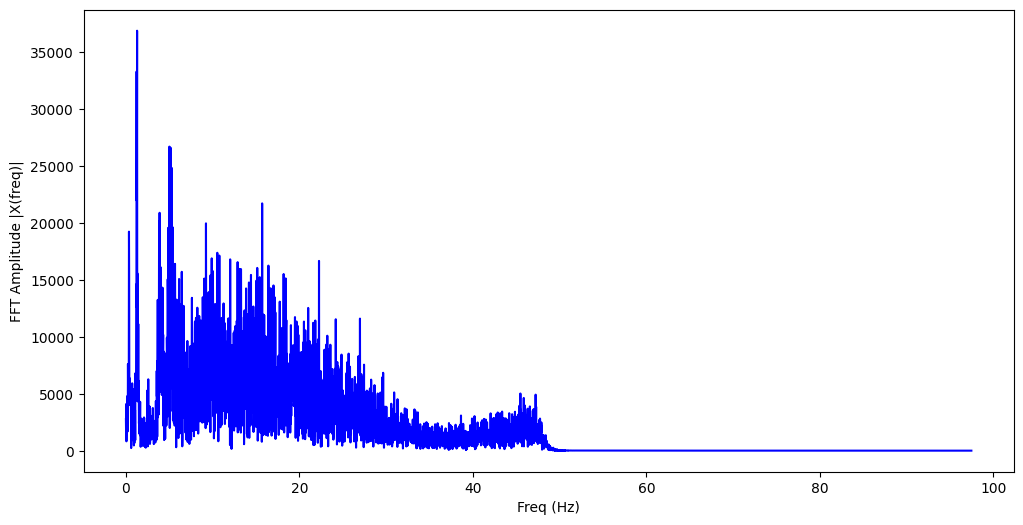

In [ ]:
import pathlib #librería para cargar datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft
import scipy
from scipy.signal import butter,lfilter,freqz

sample_rate = 195
dir_señales = ()
####SEÑAL ORIGINAL####
sample=pd.read_csv("0694.txt",header=None)
sample=np.array(sample).flatten()
sample_inverted=sample-np.mean(sample)
sample_alined=-1*sample_inverted

####FILTRO PASA BAJOS####
def butter_lowpass(cutoff, fs, order=5):
    return butter(order, cutoff, fs=fs, btype='low', analog=False)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

cutoff = 3.667 #cutoff frequency in rad/s
fs = 15 #sampling frequency in rad/s
order = 60 #order of filter

y = butter_lowpass_filter(sample_inverted, cutoff, fs, order)
plt.plot(sample_alined)

####SUAVIZADO DE LA SEÑAL####
smooth = scipy.signal.savgol_filter(y, 21, 7, mode='nearest')

####TRANSFORMADA DE FOURIER###
from scipy.fftpack import fft, ifft
X = fft(y)
N = len(X)
n = np.arange(N)
# get the sampling rate
sr = 195
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (12, 6))
plt.plot(f_oneside[1:-1], np.abs(X[:n_oneside])[1:-1], 'b')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()


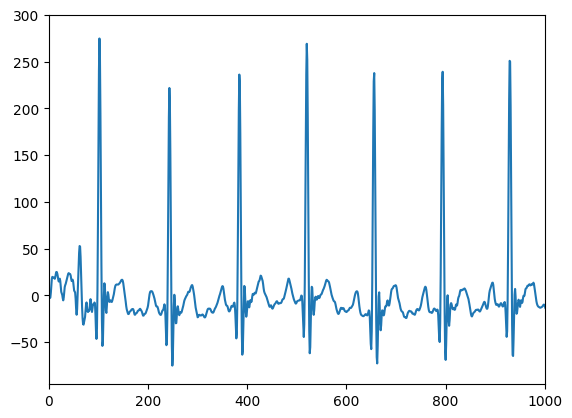

In [ ]:
plt.xlim(0,1000)
plt.plot (-1*smooth)

**Resta de distancias**

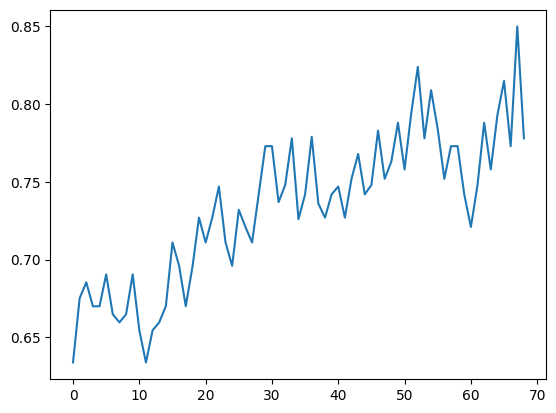

In [ ]:
ejemplo_dir = '/content/drive/MyDrive/Colab Notebooks/PYTHON/PICOS_LOCALIZADOS' #carpeta donde están los datos
#tiene que estar en la nube con permisos ilimitados
directorio = pathlib.Path(ejemplo_dir)
señales=[]
for fichero in directorio.iterdir():
  datos=pd.read_csv(fichero,names=[fichero.name])
  if len(datos)>60 and len(datos)<120:
     señales.append(datos)

distancia=[]
for i in range(0,len(señales)):
  dist1=[]

  for j in range(0,len(señales[i])-1):
    dist1.append(float(np.array(señales[i])[j+1])-float(np.array(señales[i])[j]))
  distancia.append(dist1)

plt.plot(distancia[1])






**Fourier y Log de restas de distancias**

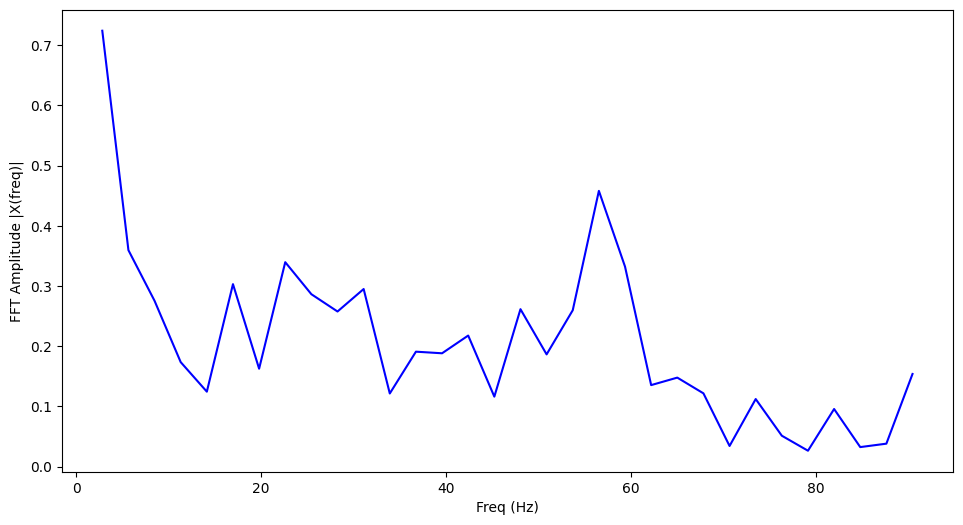

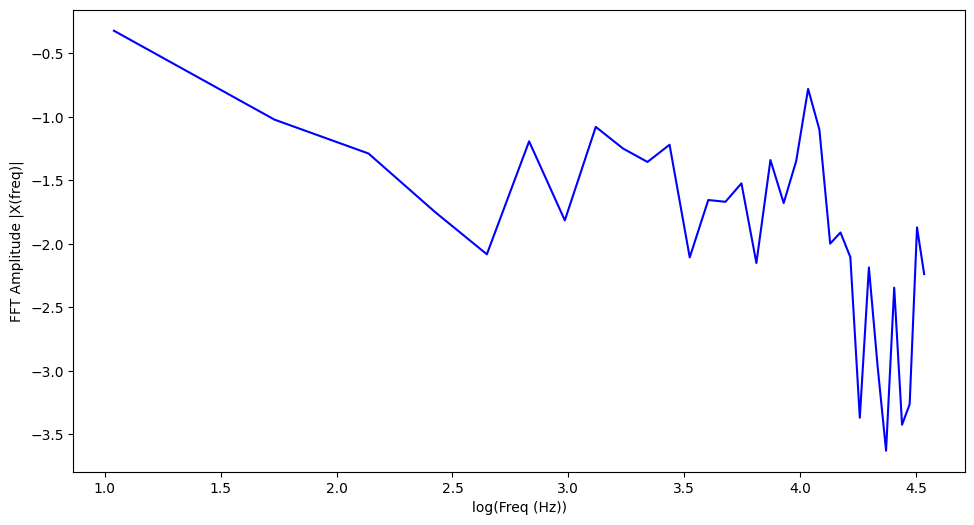

In [ ]:
from scipy.fftpack import fft, ifft
x = fft(distancia[5])
N = len(x)
n = np.arange(N)
sr = 195
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (11.5, 6))
plt.plot(f_oneside[1:-1], np.abs(x[:n_oneside])[1:-1], 'b')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

plt.figure(figsize = (11.5, 6))
plt.plot(np.log(f_oneside[1:]), np.log(np.abs(x[:n_oneside])[1:]), 'b')
plt.xlabel('log(Freq (Hz))')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

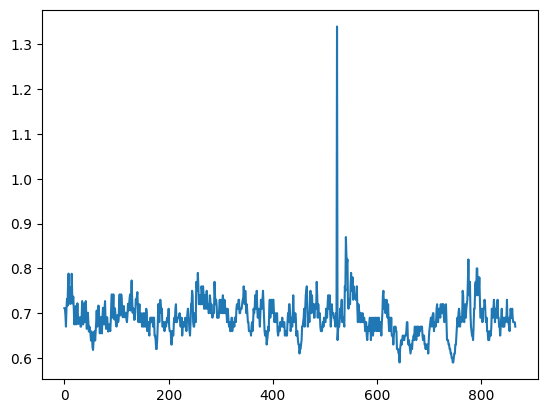

In [ ]:
dist2=[]
archivo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PYTHON/Copia de DISTANCIA_ANALIZADA.TXT')
for j in range(0, len(archivo)-1):
  dist2.append(float(np.array(archivo)[j+1])-float(np.array(archivo)[j]))

plt.plot(dist2)

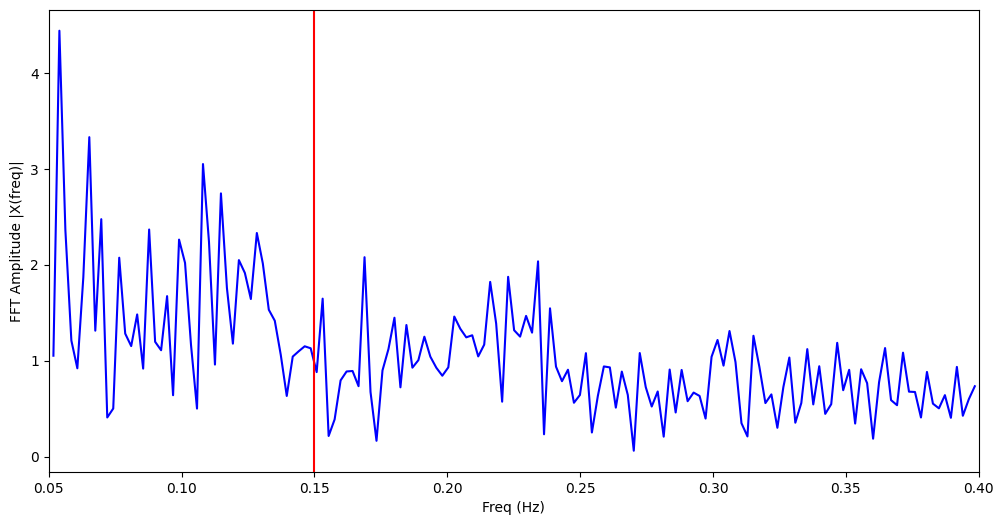

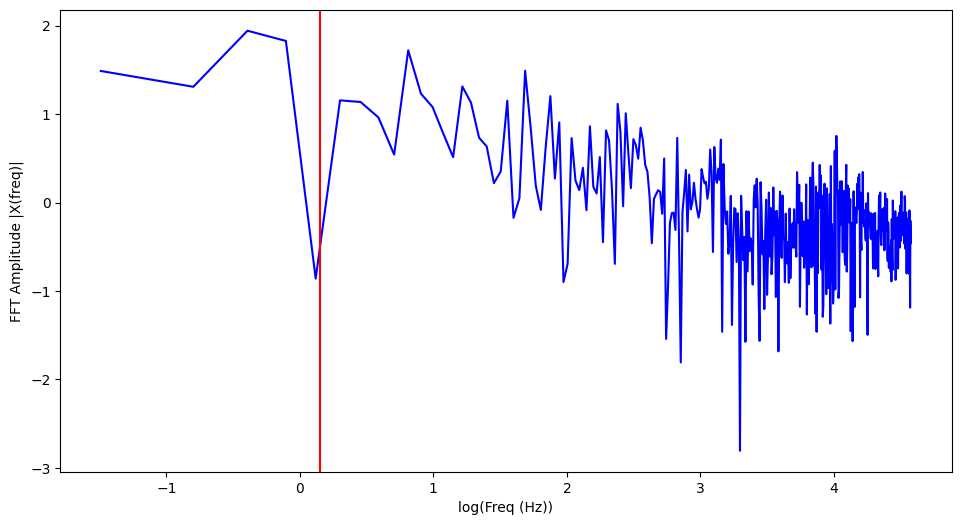

In [ ]:
from scipy.fftpack import fft, ifft
z = fft(dist2)
N = len(z)
n = np.arange(N)
# get the sampling rate
sr = 195
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (12, 6))
#plt.plot(f_oneside, np.abs(X[:n_oneside]), 'b')
ejx=f_oneside[:]/100
ejy=np.abs(z[:n_oneside])[:]
ejy=ejy[(ejx>=0.05) & (ejx<=0.4)]
ejx=ejx[(ejx>=0.05) & (ejx<=0.4)]
plt.plot(ejx, ejy, 'b')
plt.xlim((0.05,0.4))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.axvline(x = 0.15, color = 'r', linestyle = '-')
plt.show()
plt.figure(figsize = (11.5, 6))
plt.plot(np.log(f_oneside[1:]), np.log(np.abs(z[:n_oneside])[1:]), 'b')
plt.xlabel('log(Freq (Hz))')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.axvline(x = 0.15, color = 'r', linestyle = '-')
plt.show()

In [ ]:
import pathlib #librería para cargar datos
import numpy as np
import pandas as pd
import re
ejemplo_dir = '/content/drive/MyDrive/Colab Notebooks/PYTHON/MUESTRAS' #carpeta donde están los datos
#tiene que estar en la nube con permisos ilimitados
directorio = pathlib.Path(ejemplo_dir)
nombres=[]
for fichero in directorio.iterdir():
  nombres.append(fichero.name)
  r = re.compile(r"(\d+)")  #se ordenan los nombres
  nombres.sort(key=lambda x: int(r.search(x).group(1)))
  print(nombres)

señales=[] #nuevo arreglo de señales ordenados

for i in range(0,len(nombres)):
 for fichero in directorio.iterdir():
   if fichero.name==nombres[i]:
   # print("true")
    datos=pd.read_csv(fichero,names=[fichero.name])
    señales.append(datos)

In [ ]:
import math
import matplotlib.pyplot as plt
from PIL import Image as im

for i in señales:
  plt.specgram(i, Fs=195, cmap="gray")
  plt.axis("off")
#plt.savefig("spectrogram.1.png", bbox_inches='tight')
  img = im.open('spectrogram.1.png')
  imgArray = np.array(img).flatten()
  print(imgArray.shape)
  np.savetxt('test1.txt', imgArray, fmt='%d')
  a2 = np.loadtxt('test1.txt', dtype=int)
  print(imgArray == a2)
  plt.show()



NameError: ignored